# Notebook 1: Carga y preparación inicial de datos

Este notebook:
1. Carga el histórico completo del S&P 500
2. Valida el universo (composición y cobertura temporal)
3. Filtra al periodo de interés
4. Limpia símbolos y resuelve colisiones
5. Selecciona 30 activos con criterio sectorial (histórico completo + liquidez + diversidad de sector, mínimo 3 por sector)
6. Calcula retornos diarios logarítmicos
7. Revisa correlaciones y valores extremos (sanity check)
8. Guarda el dataset procesado y el mapa de sectores

La lógica pesada vive en `src/data/`; aquí solo orquestamos y visualizamos.

In [1]:
import sys
sys.path.append('..')

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_sp500_history, filter_period, summarize_universe
from src.data.cleaning import normalize_symbols, resolve_symbol_collisions
from src.data.selection import select_liquid_assets_by_sector, compute_daily_log_returns

## 1. Carga del histórico completo

In [2]:
df = load_sp500_history("../data/raw/sp500_history.parquet")
df.head()

,date,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
0,1990-01-02,AAL-199702,259078,Alexander & Alexander Services Inc Common,Financials,Insurance,NaN,1,24.765203,25.682434,24.765203,25.682434,4.145635e+04,31.50
1,1990-01-02,AAMRQ-201312,127691,AMR Corp Common,Industrials,Passenger Airlines,Passenger Airlines,1,12.304145,12.648131,12.277684,12.648131,3.148086e+06,59.75
2,1990-01-02,AAPL,136817,Apple Inc Common,Information Technology,"Technology Hardware, Storage & Peripherals","Technology Hardware, Storage & Peripherals",1,0.246931,0.262693,0.245180,0.260942,2.334998e+08,37.25
3,1990-01-02,AAV-199901,260956,Avatex Corp Common,Financials,Financial Services,Multi-Sector Holdings,1,13.964755,14.205526,13.603598,13.964755,6.074220e+04,14.50
4,1990-01-02,ABI-200811,136309,Applied Biosystems Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,1,4.056182,4.236457,4.056182,4.236457,9.235902e+05,23.50


## 2. Validación del universo

In [3]:
summary = summarize_universe(df)
print(f"Activos totales en el histórico: {summary['n_activos_totales']}")
print(f"Activos que han pertenecido al S&P 500 en algún momento: {summary['n_activos_en_indice_alguna_vez']}")

Activos totales en el histórico: 1289
Activos que han pertenecido al S&P 500 en algún momento: 1289


## 3. Filtrado al periodo de interés

Usamos el mismo periodo de backtest que nos dio Eugeni: desde el 1 de enero de 2015.

In [4]:
START_DATE = "2015-01-01"
END_DATE = df["date"].max().strftime("%Y-%m-%d")

df_period = filter_period(df, start_date=START_DATE, warmup_months=0)
print("Rango:", df_period["date"].min(), "->", df_period["date"].max())

Rango: 2015-01-02 00:00:00 -> 2026-01-30 00:00:00


## 4. Limpieza de símbolos

In [5]:
df_clean = normalize_symbols(df_period)
df_clean = resolve_symbol_collisions(df_clean)
print(f"Filas antes: {len(df_period)}, después de limpiar: {len(df_clean)}")

Filas antes: 1962222, después de limpiar: 1961489


## 5. Selección de 30 activos por sector

**Decisión:** repartimos los 30 activos entre sectores (no solo por liquidez) para
poder simular después shocks sectoriales realistas (p.ej. "más volatilidad en
banca" necesita varios bancos, no solo uno). Financials y Energy mantienen algo
más de peso, en línea con los ejemplos de la propuesta original (bancos,
energéticas).

**Decisión sobre sesgo de supervivencia:** exigimos histórico completo (~98% de
las fechas del periodo) para cada activo. Esto introduce sesgo de supervivencia
residual (excluye empresas que desaparecieron del todo), pero lo asumimos
conscientemente: los modelos generativos necesitan series alineadas sin huecos,
y como la comparación entre métodos (real vs. real+sintético) es siempre sobre
el mismo universo, el sesgo afecta por igual a todos los brazos del experimento
y no distorsiona la conclusión de cuál método funciona mejor.

**Decisión — mínimo 3 activos por sector (subido desde 2):** con solo 2
activos por sector detectamos un problema al descomponer en factores
(Notebook 2): el factor sectorial "leave-one-out" de cada activo se reducía
a la serie cruda de su único compañero (sin ningún promedio de por medio),
lo que generaba betas sectoriales con signos poco intuitivos en varios
activos (CSX, F, AAL, TSLA). Con mínimo 3 activos, el factor leave-one-out
de cada uno es la media de al menos 2 compañeros, recuperando algo de
suavizado y mitigando el problema. Ver la nota completa en el Notebook 2.

In [6]:
df_clean["sector"].unique()

<ArrowStringArray>
[           'Health Care', 'Consumer Discretionary',            'Industrials',
 'Information Technology',             'Financials',       'Consumer Staples',
              'Utilities',            'Real Estate',              'Materials',
                 'Energy', 'Communication Services',                      nan]
Length: 12, dtype: str

In [7]:
sectores_deseados = {
    "Financials": 5,
    "Energy": 4,
    "Information Technology": 3,
    "Health Care": 3,
    "Consumer Discretionary": 3,
    "Industrials": 3,
    "Consumer Staples": 3,
    "Utilities": 3,
    "Materials": 3,
}
# suma = 30, con al menos 3 activos en cada sector

selected_assets, sector_map = select_liquid_assets_by_sector(
    df_clean, start_date=START_DATE, end_date=END_DATE, n_per_sector=sectores_deseados
)
selected_assets

['BAC',
 'WFC',
 'C',
 'HBAN',
 'KEY',
 'XOM',
 'KMI',
 'RIG',
 'OXY',
 'NVDA',
 'AAPL',
 'AMD',
 'PFE',
 'BMY',
 'MRK',
 'TSLA',
 'F',
 'AMZN',
 'AAL',
 'CSX',
 'DAL',
 'WMT',
 'KO',
 'MO',
 'PCG',
 'NEE',
 'EXC',
 'FCX',
 'B',
 'CLF']

In [8]:
with open("../data/processed/asset_sectors.json", "w") as f:
    json.dump(sector_map, f, indent=2)

print("Mapa de sector guardado en data/processed/asset_sectors.json")
sector_map

Mapa de sector guardado en data/processed/asset_sectors.json


{'BAC': 'Financials',
 'WFC': 'Financials',
 'C': 'Financials',
 'HBAN': 'Financials',
 'KEY': 'Financials',
 'XOM': 'Energy',
 'KMI': 'Energy',
 'RIG': 'Energy',
 'OXY': 'Energy',
 'NVDA': 'Information Technology',
 'AAPL': 'Information Technology',
 'AMD': 'Information Technology',
 'PFE': 'Health Care',
 'BMY': 'Health Care',
 'MRK': 'Health Care',
 'TSLA': 'Consumer Discretionary',
 'F': 'Consumer Discretionary',
 'AMZN': 'Consumer Discretionary',
 'AAL': 'Industrials',
 'CSX': 'Industrials',
 'DAL': 'Industrials',
 'WMT': 'Consumer Staples',
 'KO': 'Consumer Staples',
 'MO': 'Consumer Staples',
 'PCG': 'Utilities',
 'NEE': 'Utilities',
 'EXC': 'Utilities',
 'FCX': 'Materials',
 'B': 'Materials',
 'CLF': 'Materials'}

## 6. Retornos diarios logarítmicos

In [9]:
returns = compute_daily_log_returns(df_clean, selected_assets)
returns.head()

symbol,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.000649,-0.028576,-0.011215,-0.020731,-0.000917,-0.029481,-0.015751,-0.032022,-0.075312,-0.027430,...,-0.010648,-0.017034,-0.037778,0.016732,-0.005441,-0.073259,-0.042950,-0.027805,-0.002915,-0.027743
2015-01-06,-0.015620,0.000094,-0.011342,-0.023098,0.033382,-0.030376,-0.001708,-0.035839,-0.032739,-0.040667,...,0.003877,-0.030787,-0.008535,-0.001476,0.008309,-0.022824,0.005648,-0.021085,0.007676,-0.005330
2015-01-07,-0.000566,0.013925,-0.019195,0.010544,-0.013399,0.004734,0.012912,0.009227,0.080652,0.013053,...,0.009112,-0.002870,0.000130,0.007908,0.013593,-0.009768,-0.001563,0.005934,0.026186,0.010082
2015-01-08,0.012187,0.037702,0.011561,0.006813,-0.028274,0.020451,0.024676,0.014936,0.069188,0.015790,...,0.006060,0.037189,0.008791,0.012560,0.020203,-0.001842,-0.001589,0.021896,0.020886,0.016508
2015-01-09,-0.031040,0.001072,0.007634,-0.011818,0.016514,-0.018092,-0.006609,-0.022587,-0.024863,-0.002033,...,-0.008869,0.004020,-0.001933,0.009900,0.004605,-0.010504,-0.018957,-0.016567,-0.012457,-0.001411


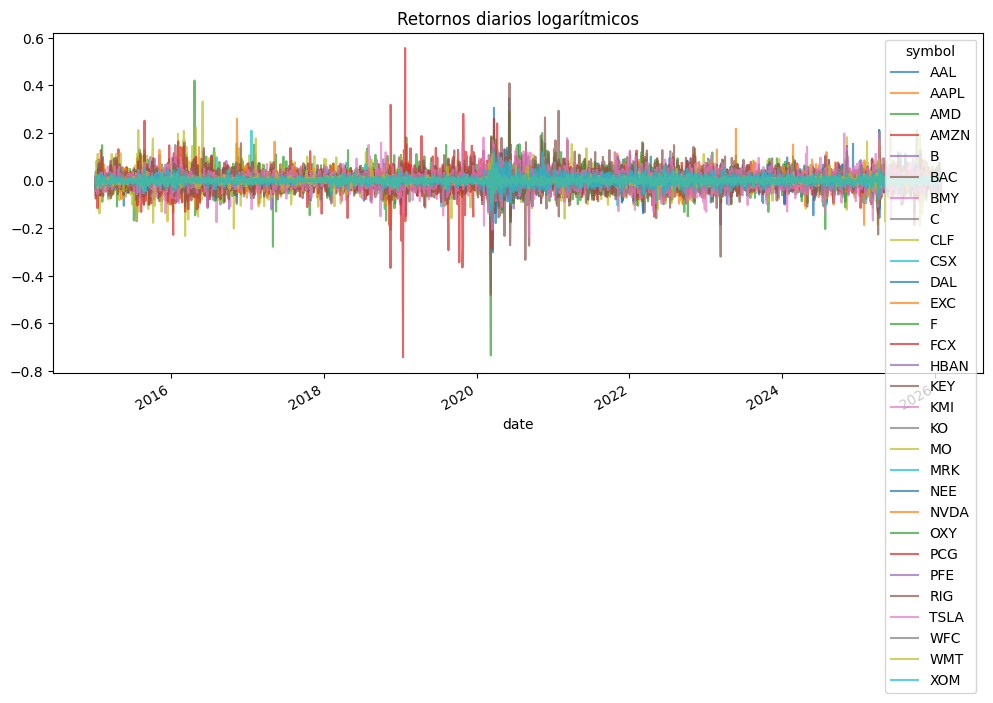

In [10]:
returns.plot(figsize=(12, 5), legend=True, title="Retornos diarios logarítmicos", alpha=0.7)
plt.show()

## 7. Sanity check: valores extremos y calidad de los datos

Antes de pasar estos datos a los modelos generativos, comprobamos que no hay
huecos (NaN) inesperados y revisamos los movimientos más extremos, para
distinguir errores de datos de eventos reales.

In [11]:
print("Valores NaN por activo:")
print(returns.isna().sum())
print("\nEstadísticos descriptivos:")
returns.describe().T[["mean", "std", "min", "max"]]

Valores NaN por activo:
symbol
AAL     0
AAPL    0
AMD     0
AMZN    0
B       0
BAC     0
BMY     0
C       0
CLF     0
CSX     0
DAL     0
EXC     0
F       0
FCX     0
HBAN    0
KEY     0
KMI     0
KO      0
MO      0
MRK     0
NEE     0
NVDA    0
OXY     0
PCG     0
PFE     0
RIG     0
TSLA    0
WFC     0
WMT     0
XOM     0
dtype: int64

Estadísticos descriptivos:


,mean,std,min,max
symbol,,,,
AAL,-0.000483,0.031833,-0.290682,0.344278
AAPL,0.000851,0.018121,-0.137708,0.142618
AMD,0.001608,0.036391,-0.277456,0.420617
AMZN,0.000984,0.020644,-0.151398,0.132178
B,0.000589,0.024960,-0.170784,0.141327
BAC,0.000474,0.019332,-0.167205,0.163786
BMY,0.000103,0.015904,-0.174176,0.108338
C,0.000378,0.020647,-0.214414,0.165381
CLF,0.000261,0.043694,-0.278020,0.332276


In [12]:
# Movimientos diarios extremos (|retorno| > 30%), para revisar caso a caso
extreme_moves = returns[(returns.abs() > 0.30)].dropna(how="all")
extreme_moves

symbol,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2016-04-22,NaN,NaN,0.420617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.332276,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-11-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.366380,NaN,NaN,NaN,NaN,NaN,NaN
2018-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.318761,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.741483,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.557289,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.343235,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.364643,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.734257,NaN,NaN,-0.479888,NaN,NaN,NaN,NaN


**Nota sobre los movimientos extremos:** cada fila de la tabla anterior tiene
NaN en casi todas las columnas porque el filtro `|retorno| > 30%` solo se
cumple para un activo concreto en cada fecha; no indica ningún problema de
datos, es el comportamiento esperado al filtrar un DataFrame ancho.

Todos los movimientos extremos detectados corresponden a eventos de mercado
reales y documentados, no a errores de datos:
- **PCG, varios días 2018-2020:** bancarrota (Chapter 11) por responsabilidad
  en los incendios forestales de California (caída máxima de -74% el
  14-01-2019).
- **AMD, 22-04-2016 (+42%):** resultados trimestrales muy por encima de lo
  esperado.
- **CLF, 31-05-2016 (+33%):** Cleveland-Cliffs (Materials), movimiento
  puntual fuerte — a confirmar el motivo concreto (probable noticia sobre
  precio del mineral de hierro o resultados).
- **OXY y RIG, 09-03-2020 (-73% y -48%):** el "Lunes Negro" del petróleo —
  colapso conjunto de la guerra de precios Arabia Saudí-Rusia y el shock de
  demanda por COVID.
- **AAL, marzo y junio de 2020:** rebotes especulativos de aerolíneas en plena
  volatilidad COVID.
- **RIG, junio-agosto 2020:** alta volatilidad en la fase de recuperación del
  precio del petróleo.

Con la ampliación a 30 activos aparecen dos filas adicionales (18-03-2020 y
13-03-2023) cuyo activo protagonista queda fuera de las columnas visibles en
esta captura; probablemente correspondan a DAL (shock COVID en aerolíneas,
coherente con la alta correlación AAL-DAL de 0.84 observada en el heatmap) y
a KEY (crisis de bancos regionales de EEUU, colapso de Silicon Valley Bank),
respectivamente — pendiente de confirmar con la tabla completa antes de
darlo por definitivo.

## 8. Matriz de correlaciones

Sirve para confirmar que existe estructura sectorial real en los datos (los
activos del mismo sector deberían correlacionar más entre sí que con el resto),
lo cual justifica poder simular después shocks sectoriales controlados.

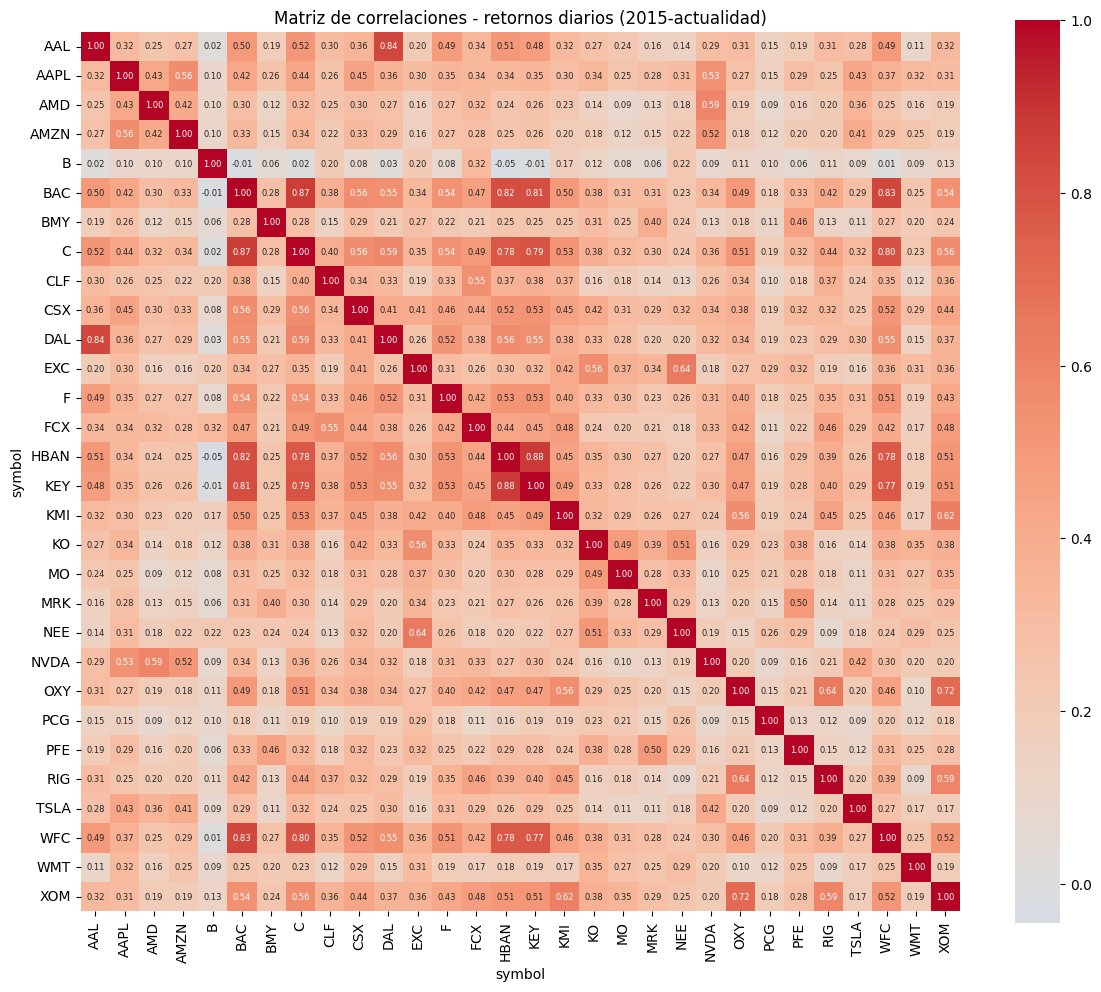

In [13]:
corr = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, annot_kws={"size": 6})
plt.title("Matriz de correlaciones - retornos diarios (2015-actualidad)")
plt.tight_layout()
plt.show()

**Lectura del heatmap:** ampliar de 2 a 3 activos por sector mejora
notablemente la cohesión sectorial visible, aunque de forma desigual entre
sectores.

- **Bancos (BAC, C, HBAN, KEY, WFC):** siguen siendo el bloque más
  cohesionado (0.77-0.88), sin cambios relevantes respecto a versiones
  anteriores.
- **Energía (XOM, KMI, RIG, OXY):** cohesión alta y consistente
  (0.45-0.72), con OXY-XOM (0.72) y RIG-OXY (0.64) como los pares más
  fuertes.
- **Industrials (AAL, CSX, DAL):** ahora es uno de los sectores más
  cohesionados del universo — AAL-DAL correlacionan 0.84 (las dos
  aerolíneas), y ambas correlacionan con CSX en torno a 0.52-0.59. Antes,
  con solo AAL y CSX, la cohesión del sector era mucho más débil.
- **Materials (FCX, B, CLF):** cohesión moderada — FCX-CLF correlacionan
  0.55 (ambas ligadas a materias primas/minería), pero B queda bastante
  descolgado del par (0.10-0.32 con sus compañeros).
- **Utilities (PCG, NEE, EXC):** NEE-EXC correlacionan fuerte (0.64), pero
  PCG sigue prácticamente descorrelacionado de ambas (0.11-0.20) —
  confirma, con un tercer activo de referencia, que el comportamiento de
  PCG está dominado por su propio evento idiosincrático (la bancarrota) y
  no por el sector.
- **Consumer Discretionary (TSLA, F, AMZN) y Consumer Staples (WMT, KO, MO):**
  cohesión moderada (0.27-0.51), sin un patrón tan marcado como banca,
  energía o industrials.

**Implicación práctica:** Financials, Energy e Industrials son ahora los
sectores más sólidos para simular shocks sectoriales limpios en el
Notebook 3; Utilities sigue siendo el caso más débil por el comportamiento
atípico de PCG, y Materials es intermedio por el descuelgue de B.

Esta estructura será la base para la descomposición en factor común (mercado
y sector) + componente idiosincrático del Notebook 2.

## 9. Guardado del dataset procesado

In [14]:
returns = returns.astype("float64")
returns.to_parquet("../data/processed/returns_daily.parquet")
print("Guardado en data/processed/returns_daily.parquet")
print(f"Shape final: {returns.shape}")

Guardado en data/processed/returns_daily.parquet
Shape final: (2785, 30)


## 10. Conclusión y decisiones tomadas

**Resumen de decisiones (16 agosto):**

1. **Fuente de datos:** S&P 500 (histórico proporcionado por Eugeni, 2015-actualidad),
   no el IBEX 35. Los ejemplos de shocks sectoriales de la propuesta original
   (Santander, Repsol) se adaptan a equivalentes del S&P 500 dentro de nuestro
   universo.

2. **Tamaño del universo:** 30 activos, no los 500 completos. Evolución:
   empezamos en 20, ampliamos a 25 para no recortar Financials/Energy al
   imponer mínimo 2 por sector, y ampliamos de nuevo a 30 (mínimo 3 por
   sector) al detectar que 2 activos por sector generaba betas sectoriales
   poco intuitivos en la descomposición de factores (Notebook 2). La
   pregunta de investigación (¿ayudan los sintéticos a predecir mejor la
   matriz de covarianzas?) es una comparación interna entre métodos sobre el
   mismo conjunto de activos, y no requiere el universo completo. Según la
   literatura revisada, 30 activos está en línea con — o por encima de — los
   tamaños de universo habituales tanto en trabajos de predicción de
   covarianza con deep learning (10-30 activos) como, especialmente, en
   trabajos de generación sintética multi-activo con GANs/VAEs (5-10 activos
   en la mayoría de la literatura reciente).

3. **Selección por sector, mínimo 3 por sector:** 5 Financials (BAC, WFC, C,
   HBAN, KEY), 4 Energy (XOM, KMI, RIG, OXY), 3 Information Technology
   (NVDA, AAPL, AMD), 3 Health Care (PFE, BMY, MRK), 3 Consumer Discretionary
   (TSLA, F, AMZN), 3 Industrials (AAL, CSX, DAL), 3 Consumer Staples (WMT,
   KO, MO), 3 Utilities (PCG, NEE, EXC), 3 Materials (FCX, B, CLF). La
   ampliación a 3 activos por sector mejoró notablemente la cohesión
   sectorial visible en Industrials (AAL-DAL: 0.84) y confirmó a Utilities
   como el sector con menor cohesión (PCG permanece descorrelacionado
   incluso con 2 compañeros de referencia).

4. **Mapa de sector guardado:** en `data/processed/asset_sectors.json`, para
   no tener que reescribirlo a mano en notebooks posteriores.

5. **Universo fijo, no dinámico (sesgo de supervivencia asumido):** se exige
   histórico completo (~98% de cobertura) por activo. Esto excluye empresas
   que desaparecieron del todo del mercado, pero se asume conscientemente
   porque los generativos necesitan series alineadas sin huecos, y la
   comparación entre métodos afecta por igual a todos los brazos del
   experimento.

6. **Casos límite:** además de los ya documentados (PCG, AMD, OXY, RIG,
   AAL), el universo de 30 activos incorpora un nuevo evento relevante:
   CLF (+33% el 31-05-2016). Pendiente confirmar los eventos de las filas
   18-03-2020 y 13-03-2023 (probablemente DAL y KEY respectivamente).

**Siguiente paso:** descomposición de cada serie en factor común (mercado /
sector) + componente idiosincrático, necesaria para poder generar escenarios
condicionados (Notebook 2).